In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

SAMPLE_N_SERIES = 150  # number of product-store combos to use (set None for full dataset)



In [2]:


# Login using e.g. `huggingface-cli login` to access this dataset
splits = {'train': 'data/train.parquet', 'eval': 'data/eval.parquet'}
train_df = pd.read_parquet("hf://datasets/Dingdong-Inc/FreshRetailNet-50K/" + splits["train"])
eval_df=pd.read_parquet("hf://datasets/Dingdong-Inc/FreshRetailNet-50K/" + splits["eval"])

In [3]:
train_df.shape #4.5 million rows

(4500000, 19)

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4500000 entries, 0 to 4499999
Data columns (total 19 columns):
 #   Column               Dtype  
---  ------               -----  
 0   city_id              int64  
 1   store_id             int64  
 2   management_group_id  int64  
 3   first_category_id    int64  
 4   second_category_id   int64  
 5   third_category_id    int64  
 6   product_id           int64  
 7   dt                   str    
 8   sale_amount          float64
 9   hours_sale           object 
 10  stock_hour6_22_cnt   int32  
 11  hours_stock_status   object 
 12  discount             float64
 13  holiday_flag         int32  
 14  activity_flag        int32  
 15  precpt               float64
 16  avg_temperature      float64
 17  avg_humidity         float64
 18  avg_wind_level       float64
dtypes: float64(6), int32(3), int64(7), object(2), str(1)
memory usage: 643.7+ MB


In [5]:
## Step 1: Explore the Dataset

#Inspect key fields, parse nested hourly sequences, and understand distributions.

In [6]:
df = pd.concat([train_df, eval_df], ignore_index=True)
print(f"Combined shape: {df.shape}")

df["dt"] = pd.to_datetime(df["dt"])
print(f"Date range: {df['dt'].min()} → {df['dt'].max()}")

n_products = df["product_id"].nunique()
n_stores = df["store_id"].nunique()
print(f"Products: {n_products}, Stores: {n_stores}, Unique product-store combos: {df.groupby(['product_id','store_id']).ngroups}")
#50 000 product-store combos

df.head(3)

Combined shape: (4850000, 19)
Date range: 2024-03-28 00:00:00 → 2024-07-02 00:00:00
Products: 865, Stores: 898, Unique product-store combos: 50000


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0,0,0,5,6,65,38,2024-03-28,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,1.6999,15.48,73.54,1.97
1,0,0,0,5,6,65,38,2024-03-29,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.0, ...",1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,3.0190,15.08,76.56,1.71
2,0,0,0,5,6,65,38,2024-03-30,0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,1,0,2.0942,15.91,76.47,1.73


hours_sale sample (len=24): [0. 0. 0. 0. 0. 0.]...
hours_stock_status sample (len=24): [0. 0. 0. 0. 0. 0.]...

Stockout hours (6-22) distribution:
count    4.850000e+06
mean     3.159911e+00
std      4.587389e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      6.000000e+00
max      1.600000e+01
Name: stock_hour6_22_cnt, dtype: float64


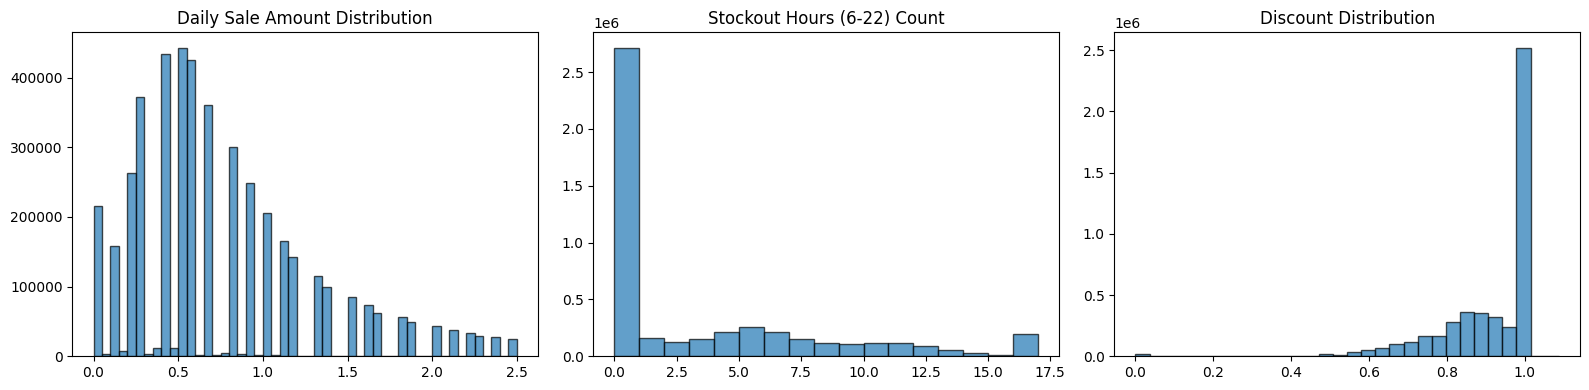

In [7]:
def parse_sequence(val):
    """Parse string-encoded lists into numpy arrays."""
    if isinstance(val, (list, np.ndarray)):
        return np.array(val, dtype=np.float64)
    if isinstance(val, str):
        return np.array(ast.literal_eval(val), dtype=np.float64)
    return val

sample_hours_sale = parse_sequence(df["hours_sale"].iloc[0])
sample_stock_status = parse_sequence(df["hours_stock_status"].iloc[0])
print(f"hours_sale sample (len={len(sample_hours_sale)}): {sample_hours_sale[:6]}...")
print(f"hours_stock_status sample (len={len(sample_stock_status)}): {sample_stock_status[:6]}...")
print(f"\nStockout hours (6-22) distribution:\n{df['stock_hour6_22_cnt'].describe()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df["sale_amount"], bins=50, range=(0, 2.5), edgecolor="k", alpha=0.7)
axes[0].set_title("Daily Sale Amount Distribution")
axes[1].hist(df["stock_hour6_22_cnt"], bins=range(0, 18), edgecolor="k", alpha=0.7)
axes[1].set_title("Stockout Hours (6-22) Count")
axes[2].hist(df["discount"], bins=30, edgecolor="k", alpha=0.7)
axes[2].set_title("Discount Distribution")
plt.tight_layout()
plt.show()

In [8]:
SAMPLE_N_SERIES = 150

In [9]:
# Subsample product-store combinations for tractable processing
if SAMPLE_N_SERIES is not None:
    combos = df.groupby(["product_id", "store_id"]).size().reset_index(name="n_days")
    combos = combos.sort_values("n_days", ascending=False).head(SAMPLE_N_SERIES)
    df = df.merge(combos[["product_id", "store_id"]], on=["product_id", "store_id"])
    print(f"Sampled {SAMPLE_N_SERIES} product-store combos → {len(df)} rows")
else:
    print(f"Using full dataset: {len(df)} rows")

df = df.sort_values(["product_id", "store_id", "dt"]).reset_index(drop=True)

Sampled 150 product-store combos → 14550 rows


In [10]:
df.groupby(["product_id", "store_id"]).ngroups
# df is now top 100 product-store combos


150

In [11]:
df.head()

,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,1,25,2,31,79,227,0,2024-03-28,0.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,9.2058,24.25,80.07,1.34
1,1,25,2,31,79,227,0,2024-03-29,0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,6.4144,24.55,80.18,1.29
2,1,25,2,31,79,227,0,2024-03-30,0.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,1,0,6.4818,23.78,78.53,1.18
3,1,25,2,31,79,227,0,2024-03-31,0.2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,1,0,7.4062,24.26,77.19,1.55
4,1,25,2,31,79,227,0,2024-04-01,0.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.0,0,0,10.3144,24.98,77.93,1.21


## Step 2: Reconstruct Latent Demand

For hours where `hours_stock_status == 1` the observed sale is zero but true demand is censored. We impute using the average of the same hour on adjacent in-stock days. For longer stockouts an XGBoost model trained on in-stock hours generates predictions.

In [12]:
df["hours_sale"] = df["hours_sale"].apply(parse_sequence)
df["hours_stock_status"] = df["hours_stock_status"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=np.int32) if isinstance(x, str) else np.array(x, dtype=np.int32)
)

stockout_counts = df["hours_stock_status"].apply(lambda x: x.sum())
print(f"Rows with any stockout hour: {(stockout_counts > 0).sum()} / {len(df)}")
print(f"Mean stockout hours per day: {stockout_counts.mean():.2f}")

Rows with any stockout hour: 8720 / 14550
Mean stockout hours per day: 6.18


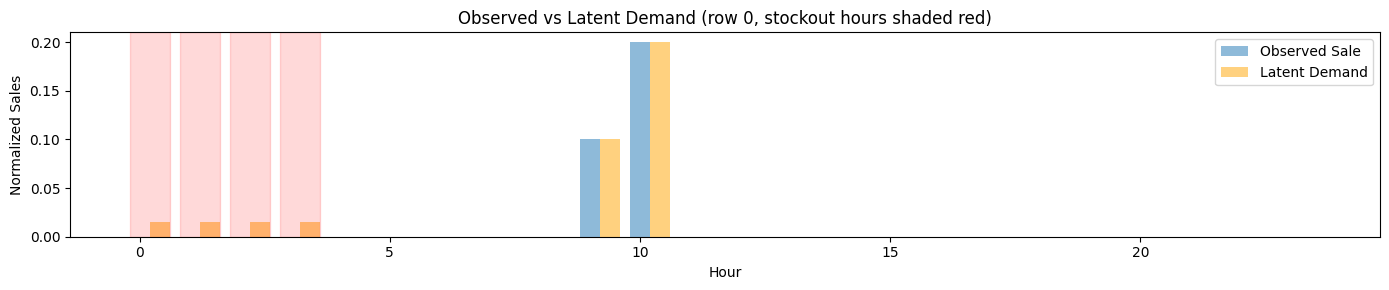

In [13]:
def reconstruct_latent_demand(group):
    """
    For each product-store group, impute censored hours using same-hour
    averages from nearby in-stock days (±7 days window).
    """
    group = group.sort_values("dt").reset_index(drop=True)
    n_days = len(group)
    all_sales = np.stack(group["hours_sale"].values)        # (n_days, 24)
    all_status = np.stack(group["hours_stock_status"].values)  # (n_days, 24)
    latent = all_sales.copy()

    for d in range(n_days):
        stockout_hours = np.where(all_status[d] == 1)[0] #returns indices of where stockout is true
        if len(stockout_hours) == 0:
            continue
        for h in stockout_hours:
            window_start = max(0, d - 7)
            window_end = min(n_days, d + 8)
            in_stock_vals = []
            for w in range(window_start, window_end):
                if w != d and all_status[w, h] == 0 and all_sales[w, h] > 0:
                    in_stock_vals.append(all_sales[w, h])
            if len(in_stock_vals) >= 2:
                latent[d, h] = np.mean(in_stock_vals)
            else:
                # Fallback: use the daily mean of in-stock hours for that day
                in_stock_today = all_sales[d, all_status[d] == 0]
                latent[d, h] = in_stock_today.mean() if len(in_stock_today) > 0 else 0.0

    group["latent_demand"] = list(latent)
    return group

_groups = []
for _, grp in df.groupby(["product_id", "store_id"]):
    _groups.append(reconstruct_latent_demand(grp))
df = pd.concat(_groups, ignore_index=True)
del _groups

sample_idx = df[df["hours_stock_status"].apply(lambda x: x.sum()) > 3].index[0]
fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(24), df.loc[sample_idx, "hours_sale"], alpha=0.5, label="Observed Sale", width=0.4)
ax.bar(np.arange(24) + 0.4, df.loc[sample_idx, "latent_demand"], alpha=0.5, label="Latent Demand", width=0.4, color="orange")
stockout_mask = df.loc[sample_idx, "hours_stock_status"] == 1
for h in np.where(stockout_mask)[0]:
    ax.axvspan(h - 0.2, h + 0.6, alpha=0.15, color="red")
ax.set_xlabel("Hour")
ax.set_ylabel("Normalized Sales")
ax.set_title(f"Observed vs Latent Demand (row {sample_idx}, stockout hours shaded red)")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3: Reshape from Daily Rows to Hourly Long-Format

Unnest the 24-hour sequences so each row is a single hour observation with `unique_id`, `ds`, and `y` (latent demand).

In [14]:
def expand_to_hourly(row): # day
    """Expand a single daily row into 24 hourly rows."""
    base_dt = row["dt"]
    latent = row["latent_demand"]
    stock_status = row["hours_stock_status"]
    hours_sale_raw = row["hours_sale"]
    records = []
    for h in range(24):
        records.append({
            "unique_id": f"{row['product_id']}_{row['store_id']}",
            "ds": base_dt + timedelta(hours=h),
            "y": latent[h],
            "observed_sale": hours_sale_raw[h],
            "stockout_flag": int(stock_status[h]),
            "product_id": row["product_id"],
            "store_id": row["store_id"],
            "city_id": row["city_id"],
            "first_category_id": row["first_category_id"],
            "second_category_id": row["second_category_id"],
            "third_category_id": row["third_category_id"],
            "discount": row["discount"],
            "holiday_flag": row["holiday_flag"],
            "activity_flag": row["activity_flag"],
            "precpt": row["precpt"],
            "avg_temperature": row["avg_temperature"],
            "avg_humidity": row["avg_humidity"],
            "avg_wind_level": row["avg_wind_level"],
        })
    return records

print("Expanding to hourly format...")
all_records = []
for _, row in df.iterrows():
    all_records.extend(expand_to_hourly(row))

hourly_df = pd.DataFrame(all_records)
hourly_df = hourly_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
print(f"Hourly dataframe shape: {hourly_df.shape}")
hourly_df.head()

Expanding to hourly format...
Hourly dataframe shape: (349200, 18)


,unique_id,ds,y,observed_sale,stockout_flag,product_id,store_id,city_id,first_category_id,second_category_id,third_category_id,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level
0,0_25,2024-03-28 00:00:00,0.015,0.0,1,0,25,1,31,79,227,1.0,0,0,9.2058,24.25,80.07,1.34
1,0_25,2024-03-28 01:00:00,0.015,0.0,1,0,25,1,31,79,227,1.0,0,0,9.2058,24.25,80.07,1.34
2,0_25,2024-03-28 02:00:00,0.015,0.0,1,0,25,1,31,79,227,1.0,0,0,9.2058,24.25,80.07,1.34
3,0_25,2024-03-28 03:00:00,0.015,0.0,1,0,25,1,31,79,227,1.0,0,0,9.2058,24.25,80.07,1.34
4,0_25,2024-03-28 04:00:00,0.000,0.0,0,0,25,1,31,79,227,1.0,0,0,9.2058,24.25,80.07,1.34


In [15]:
unique_id_counts = hourly_df.groupby("unique_id").size().reset_index(name="count")
print(unique_id_counts.head())

  unique_id  count
0      0_25   2328
1   554_522   2328
2   554_524   2328
3   554_525   2328
4   554_526   2328


## Step 4: Create Temporal Features

Cyclical encodings for hour, day-of-week, month, plus binary weekend/holiday/activity flags.

In [16]:
hourly_df["hour"] = hourly_df["ds"].dt.hour
hourly_df["day_of_week"] = hourly_df["ds"].dt.dayofweek
hourly_df["month"] = hourly_df["ds"].dt.month
hourly_df["week_of_year"] = hourly_df["ds"].dt.isocalendar().week.astype(int)
hourly_df["day"] = hourly_df["ds"].dt.day
hourly_df["is_weekend"] = (hourly_df["day_of_week"] >= 5).astype(int)

# Cyclical encodings
for col, period in [("hour", 24), ("day_of_week", 7), ("month", 12), ("week_of_year", 52)]:
    hourly_df[f"{col}_sin"] = np.sin(2 * np.pi * hourly_df[col] / period)
    hourly_df[f"{col}_cos"] = np.cos(2 * np.pi * hourly_df[col] / period)

# Days since / until next promotion & stockout (computed per unique_id)
def days_since_until(series):
    """For a binary flag series, compute days since last 1 and days until next 1."""
    vals = series.values
    n = len(vals)
    since = np.full(n, np.nan)
    until = np.full(n, np.nan)
    last_event = -999
    for i in range(n):
        if vals[i] == 1:
            last_event = i
        if last_event >= 0:
            since[i] = i - last_event
    next_event = n + 999
    for i in range(n - 1, -1, -1):
        if vals[i] == 1:
            next_event = i
        if next_event < n:
            until[i] = next_event - i
    return since, until

for flag, prefix in [("activity_flag", "promo"), ("stockout_flag", "stockout")]:
    since_list, until_list = [], []
    for uid, grp in hourly_df.groupby("unique_id"):
        s, u = days_since_until(grp[flag])
        since_list.append(pd.Series(s, index=grp.index))
        until_list.append(pd.Series(u, index=grp.index))
    hourly_df[f"hours_since_{prefix}"] = pd.concat(since_list)
    hourly_df[f"hours_until_{prefix}"] = pd.concat(until_list)

hourly_df[["hours_since_promo", "hours_until_promo", "hours_since_stockout", "hours_until_stockout"]].describe()

,hours_since_promo,hours_until_promo,hours_since_stockout,hours_until_stockout
count,345528.000000,321024.000000,346718.000000,346672.000000
mean,172.678440,144.143017,49.385544,49.349616
std,248.774984,211.064685,74.135709,74.102853
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,50.000000,32.000000,19.000000,19.000000
75%,262.000000,224.000000,67.000000,67.000000
max,1248.000000,1104.000000,635.000000,635.000000


## Step 5: Create Lag Features

Lags at 1–6 hours (intra-day), 24h (same hour yesterday), 48h, 168h (same hour last week), 336h, 720h (monthly).

In [17]:
lag_periods = [1, 2, 3, 4, 5, 6, 24, 48, 168, 336, 720]

for lag in lag_periods:
    hourly_df[f"lag_{lag}"] = hourly_df.groupby("unique_id")["y"].shift(lag)

print(f"Lag features created: {[f'lag_{l}' for l in lag_periods]}")
hourly_df[[f"lag_{l}" for l in lag_periods]].describe().round(4)

Lag features created: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_24', 'lag_48', 'lag_168', 'lag_336', 'lag_720']


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_24,lag_48,lag_168,lag_336,lag_720
count,349050.0000,348900.0000,348750.0000,348600.0000,348450.0000,348300.0000,345600.0000,342000.0000,324000.0000,298800.0000,241200.0000
mean,0.0521,0.0521,0.0521,0.0521,0.0521,0.0521,0.0521,0.0520,0.0522,0.0531,0.0534
std,0.0805,0.0805,0.0805,0.0805,0.0805,0.0805,0.0805,0.0805,0.0805,0.0806,0.0805
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.1000,0.1000,0.1000,0.1000,0.1000,0.1000,0.1000,0.1000,0.1000,0.1000,0.1000
max,1.5000,1.5000,1.5000,1.5000,1.5000,1.5000,1.5000,1.5000,1.5000,1.5000,1.5000


## Step 6: Rolling Statistics

Rolling mean, std, min, max over 6h, 24h, 168h windows. Also lagged rolling stats for baseline comparison.

In [18]:
rolling_windows = [6, 24, 168]

for w in rolling_windows:
    grp = hourly_df.groupby("unique_id")["y"]
    hourly_df[f"rolling_mean_{w}h"] = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    hourly_df[f"rolling_std_{w}h"] = grp.transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())

grp24 = hourly_df.groupby("unique_id")["y"]
hourly_df["rolling_min_24h"] = grp24.transform(lambda x: x.shift(1).rolling(24, min_periods=1).min())
hourly_df["rolling_max_24h"] = grp24.transform(lambda x: x.shift(1).rolling(24, min_periods=1).max())

# Lagged rolling means for comparative baselines
for lag_offset in [24, 168]:
    for w in [24, 168]:
        col = f"rolling_mean_{w}h"
        if col in hourly_df.columns:
            hourly_df[f"{col}_lag{lag_offset}"] = hourly_df.groupby("unique_id")[col].shift(lag_offset)

print("Rolling features created.")
hourly_df.filter(like="rolling").describe().round(4)

Rolling features created.


,rolling_mean_6h,rolling_std_6h,rolling_mean_24h,rolling_std_24h,rolling_mean_168h,rolling_std_168h,rolling_min_24h,rolling_max_24h,rolling_mean_24h_lag24,rolling_mean_168h_lag24,rolling_mean_24h_lag168,rolling_mean_168h_lag168
count,349050.0000,348900.0000,349050.0000,348900.0000,349050.0000,348900.0000,349050.0000,349050.0000,345450.0000,345450.0000,323850.0000,323850.0000
mean,0.0521,0.0488,0.0520,0.0659,0.0515,0.0721,0.0005,0.2421,0.0519,0.0515,0.0521,0.0522
std,0.0528,0.0452,0.0377,0.0302,0.0262,0.0229,0.0067,0.1297,0.0376,0.0262,0.0373,0.0261
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0167,0.0065,0.0248,0.0467,0.0316,0.0559,0.0000,0.2000,0.0247,0.0317,0.0250,0.0326
50%,0.0333,0.0408,0.0429,0.0618,0.0465,0.0689,0.0000,0.2000,0.0429,0.0466,0.0438,0.0473
75%,0.0833,0.0753,0.0712,0.0797,0.0663,0.0842,0.0000,0.3000,0.0711,0.0663,0.0713,0.0667
max,0.7500,0.5854,0.4114,0.3937,0.2167,0.1911,0.2167,1.5000,0.4114,0.2167,0.4114,0.2167


## Step 7: Interaction Features

Synergistic combinations of discount, holiday, weather, and time-of-day features.

In [19]:
hourly_df["discount_x_holiday"] = hourly_df["discount"] * hourly_df["holiday_flag"]
hourly_df["temp_x_hour_sin"] = hourly_df["avg_temperature"] * hourly_df["hour_sin"]
hourly_df["precpt_x_weekend"] = hourly_df["precpt"] * hourly_df["is_weekend"]
hourly_df["prev_day_sale_x_discount"] = hourly_df["lag_24"] * hourly_df["discount"]

print("Interaction features created.")
hourly_df[["discount_x_holiday", "temp_x_hour_sin", "precpt_x_weekend", "prev_day_sale_x_discount"]].describe().round(4)

Interaction features created.


,discount_x_holiday,temp_x_hour_sin,precpt_x_weekend,prev_day_sale_x_discount
count,349200.0000,349200.0000,349200.0000,345600.0000
mean,0.3128,-0.0000,1.0011,0.0471
std,0.4407,16.0889,2.2693,0.0721
min,0.0000,-31.7200,0.0000,0.0000
25%,0.0000,-14.9350,0.0000,0.0000
50%,0.0000,0.0000,0.0000,0.0000
75%,0.8580,14.9350,1.0252,0.0884
max,1.0000,31.7200,22.6358,1.2885


## Step 8: Hierarchical Aggregation Features

Capture cross-product and cross-store dynamics at the category and store level.

In [20]:
# Category-level mean (same category across all stores for this timestamp)
hourly_df["cat_store_mean"] = hourly_df.groupby(
    ["first_category_id", "store_id", "ds"])["y"].transform("mean")

# Store-level mean (all products in a store for this timestamp)
hourly_df["store_mean"] = hourly_df.groupby(["store_id", "ds"])["y"].transform("mean")

# Category-level mean (all stores for this timestamp)
hourly_df["category_mean"] = hourly_df.groupby(["first_category_id", "ds"])["y"].transform("mean")

print("Hierarchical features created.")
hourly_df[["cat_store_mean", "store_mean", "category_mean"]].describe().round(4)

Hierarchical features created.


,cat_store_mean,store_mean,category_mean
count,349200.0000,349200.0000,349200.0000
mean,0.0521,0.0521,0.0521
std,0.0805,0.0802,0.0372
min,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0250
50%,0.0000,0.0000,0.0439
75%,0.1000,0.1000,0.0715
max,1.5000,1.5000,0.5000


## Step 9: Prepare Final Dataset — Handle Gaps, Normalize, and Split

Ensure continuity, standardize features using training statistics only, and split chronologically into train / val / test.

In [21]:
from sklearn.preprocessing import StandardScaler
import pickle, os

# Forward-fill short gaps (up to 6 hours); mark longer gaps
hourly_df = hourly_df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
hourly_df = hourly_df.ffill(limit=6)

# Drop rows that still have NaN target (from initial lag burn-in)
pre_drop = len(hourly_df)
hourly_df = hourly_df.dropna(subset=["y"]).reset_index(drop=True)
print(f"Dropped {pre_drop - len(hourly_df)} rows with NaN target after lag burn-in")

# Identify numeric feature columns for scaling
id_cols = ["unique_id", "ds", "product_id", "store_id", "city_id",
           "first_category_id", "second_category_id", "third_category_id"]
target_col = "y"
feature_cols = [c for c in hourly_df.columns if c not in id_cols + [target_col, "observed_sale"]]

# Chronological split per unique_id: 70% train / 15% val / 15% test
def chrono_split(group):
    n = len(group)
    group = group.sort_values("ds")
    group["split"] = "train"
    group.iloc[int(n * 0.70):int(n * 0.85), group.columns.get_loc("split")] = "val"
    group.iloc[int(n * 0.85):, group.columns.get_loc("split")] = "test"
    return group

_split_groups = []
for _, grp in hourly_df.groupby("unique_id"):
    _split_groups.append(chrono_split(grp))
hourly_df = pd.concat(_split_groups, ignore_index=True)
del _split_groups
print(hourly_df["split"].value_counts())

# Fit scaler on training data only
train_mask = hourly_df["split"] == "train"
scaler = StandardScaler()
numeric_feats = hourly_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

scaler.fit(hourly_df.loc[train_mask, numeric_feats])
hourly_df[numeric_feats] = scaler.transform(hourly_df[numeric_feats])

os.makedirs("../artifacts", exist_ok=True)
with open("../artifacts/feature_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"\nFinal dataset shape: {hourly_df.shape}")
print(f"Features: {len(numeric_feats)} numeric columns")
hourly_df.head()

Dropped 0 rows with NaN target after lag burn-in
split
train    244350
test      52500
val       52350
Name: count, dtype: int64

Final dataset shape: (349200, 67)
Features: 56 numeric columns


,unique_id,ds,y,observed_sale,stockout_flag,product_id,store_id,city_id,first_category_id,second_category_id,third_category_id,discount,holiday_flag,activity_flag,precpt,...,rolling_std_168h,rolling_min_24h,rolling_max_24h,rolling_mean_24h_lag24,rolling_mean_168h_lag24,rolling_mean_24h_lag168,rolling_mean_168h_lag168,discount_x_holiday,temp_x_hour_sin,precpt_x_weekend,prev_day_sale_x_discount,cat_store_mean,store_mean,category_mean,split
0,0_25,2024-03-28 00:00:00,0.015,0.0,1.600254,0,25,1,31,79,227,0.541233,-0.7396,-0.616114,5.04632,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.730774,-0.001488,-0.513339,NaN,-0.477491,-0.479214,-1.022046,train
1,0_25,2024-03-28 01:00:00,0.015,0.0,1.600254,0,25,1,31,79,227,0.541233,-0.7396,-0.616114,5.04632,...,NaN,2.098802,-1.777682,NaN,NaN,NaN,NaN,-0.730774,0.428410,-0.513339,NaN,-0.477491,-0.479214,-1.022046,train
2,0_25,2024-03-28 02:00:00,0.015,0.0,1.600254,0,25,1,31,79,227,0.541233,-0.7396,-0.616114,5.04632,...,-3.178345,2.098802,-1.777682,NaN,NaN,NaN,NaN,-0.730774,0.829011,-0.513339,NaN,-0.477491,-0.479214,-1.022046,train
3,0_25,2024-03-28 03:00:00,0.015,0.0,1.600254,0,25,1,31,79,227,0.541233,-0.7396,-0.616114,5.04632,...,-3.178345,2.098802,-1.777682,NaN,NaN,NaN,NaN,-0.730774,1.173014,-0.513339,NaN,-0.477491,-0.479214,-1.022046,train
4,0_25,2024-03-28 04:00:00,0.000,0.0,-0.624901,0,25,1,31,79,227,0.541233,-0.7396,-0.616114,5.04632,...,-3.178345,2.098802,-1.777682,NaN,NaN,NaN,NaN,-0.730774,1.436978,-0.513339,NaN,-0.664159,-0.666556,-1.421600,train


## Step 10: LSTM Demand Forecasting Model

Sequence length = 168 hours (7 days). Forecast horizon = 24 hours.
Architecture: 2-layer LSTM (128 → 64) with dropout, trained via NeuralForecast.

In [22]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM as NF_LSTM
from neuralforecast.losses.pytorch import MAE, MQLoss

HORIZON = 24
INPUT_SIZE = 168

# Prepare the NeuralForecast-compatible dataframe (requires: unique_id, ds, y)
# Use the un-scaled target for model training (NeuralForecast handles its own normalization)
nf_df = hourly_df[["unique_id", "ds", "y", "split"]].copy()

# Static exogenous features (mapped per unique_id)
static_cols = ["product_id", "store_id", "city_id", "first_category_id"]
static_df = hourly_df.groupby("unique_id")[static_cols].first().reset_index()

# Futuristic exogenous: features known in advance (temporal encodings, holiday, discount)
futr_cols = [
    "hour_sin", "hour_cos", "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos", "is_weekend", "holiday_flag", "activity_flag", "discount"
]

# Historical exogenous: features only known historically
hist_cols = [
    "avg_temperature", "avg_humidity", "avg_wind_level", "precpt",
    "stockout_flag", "store_mean", "category_mean"
]

# Merge exogenous features into nf_df
for col in futr_cols + hist_cols:
    nf_df[col] = hourly_df[col].values

nf_train = nf_df[nf_df["split"] == "train"].drop(columns=["split"])
nf_val = nf_df[nf_df["split"] == "val"].drop(columns=["split"])
nf_test = nf_df[nf_df["split"] == "test"].drop(columns=["split"])

print(f"Train: {len(nf_train):,}  Val: {len(nf_val):,}  Test: {len(nf_test):,}")

Train: 244,350  Val: 52,350  Test: 52,500


In [23]:
lstm_model = NF_LSTM(
    h=HORIZON,
    input_size=INPUT_SIZE,
    encoder_hidden_size=128,
    encoder_n_layers=2,
    encoder_dropout=0.25,
    decoder_hidden_size=128,
    decoder_layers=2,
    futr_exog_list=futr_cols,
    hist_exog_list=hist_cols,
    loss=MAE(),
    valid_loss=MAE(),
    max_steps=500,
    batch_size=64,
    learning_rate=5e-4,
    early_stop_patience_steps=15,
    val_check_steps=50,
    scaler_type="standard",
    random_seed=42,
)

nf_lstm = NeuralForecast(models=[lstm_model], freq="h")
nf_lstm.fit(df=nf_train, val_size=HORIZON * 7)

lstm_preds = nf_lstm.predict(futr_df=nf_val)
lstm_preds = lstm_preds.reset_index()
print(f"LSTM predictions shape: {lstm_preds.shape}")
lstm_preds.head()

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ valid_loss   │ MAE           │      0 │ train │     0 │
│ 2 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 3 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 4 │ hist_encoder │ LSTM          │  207 K │ train │     0 │
│ 5 │ mlp_decoder  │ MLP           │ 17.9 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 225 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 225 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=500` reached.


Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

LSTM predictions shape: (3600, 4)


,index,unique_id,ds,LSTM
0,0,0_25,2024-06-03 21:00:00,0.008946
1,1,0_25,2024-06-03 22:00:00,0.008812
2,2,0_25,2024-06-03 23:00:00,0.008599
3,3,0_25,2024-06-04 00:00:00,0.009173
4,4,0_25,2024-06-04 01:00:00,0.009361


## Step 11: Temporal Fusion Transformer (TFT)

Probabilistic quantile forecasts (0.1, 0.5, 0.9) with multi-head attention. Captures known future inputs, historical exogenous, and static covariates.

In [ ]:
from neuralforecast.models import TFT

tft_model = TFT(
    h=HORIZON,
    input_size=INPUT_SIZE,
    hidden_size=64,
    n_head=4,
    dropout=0.15,
    futr_exog_list=futr_cols,
    hist_exog_list=hist_cols,
    loss=MQLoss(quantiles=[0.1, 0.5, 0.9]),
    valid_loss=MQLoss(quantiles=[0.1, 0.5, 0.9]),
    max_steps=500,
    batch_size=64,
    learning_rate=5e-4,
    early_stop_patience_steps=15,
    val_check_steps=50,
    scaler_type="standard",
    random_seed=42,
)

nf_tft = NeuralForecast(models=[tft_model], freq="h")
nf_tft.fit(df=nf_train, val_size=HORIZON * 7)

tft_preds = nf_tft.predict(futr_df=nf_val)
tft_preds = tft_preds.reset_index()
print(f"TFT predictions shape: {tft_preds.shape}")
tft_preds.head()

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MQLoss                   │      3 │ train │     0 │
│ 1 │ valid_loss              │ MQLoss                   │      3 │ train │     0 │
│ 2 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 3 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 4 │ embedding               │ TFTEmbedding             │  2.3 K │ train │     0 │
│ 5 │ temporal_encoder        │ TemporalCovariateEncoder │  706 K │ train │     0 │
│ 6 │ temporal_fusion_decoder │ TemporalFusionDecoder    │ 64.8 K │ train │     0 │
│ 7 │ output_adapter          │ Linear                   │    195 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 773 K                                                                                            
Non-trainable params: 6                                                                                            
Total params: 773 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 289                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()


Detected KeyboardInterrupt, attempting graceful shutdown ...


## Step 12: Training Diagnostics & Validation

Compare LSTM and TFT on MAE, RMSE, and bias metrics. Visualize forecasts for sample series.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Merge actual values with predictions for evaluation
val_actuals = nf_val.groupby("unique_id").tail(len(lstm_preds[lstm_preds["unique_id"] == lstm_preds["unique_id"].iloc[0]])).copy()

# Align predictions with actuals
eval_df_merged = lstm_preds[["unique_id", "ds", "LSTM"]].merge(
    tft_preds[["unique_id", "ds", "TFT-median"]],
    on=["unique_id", "ds"],
    how="inner"
).merge(
    nf_val[["unique_id", "ds", "y"]],
    on=["unique_id", "ds"],
    how="inner"
)

if len(eval_df_merged) > 0:
    mae_lstm = mean_absolute_error(eval_df_merged["y"], eval_df_merged["LSTM"])
    rmse_lstm = np.sqrt(mean_squared_error(eval_df_merged["y"], eval_df_merged["LSTM"]))
    bias_lstm = (eval_df_merged["LSTM"] - eval_df_merged["y"]).mean()

    mae_tft = mean_absolute_error(eval_df_merged["y"], eval_df_merged["TFT-median"])
    rmse_tft = np.sqrt(mean_squared_error(eval_df_merged["y"], eval_df_merged["TFT-median"]))
    bias_tft = (eval_df_merged["TFT-median"] - eval_df_merged["y"]).mean()

    # Naive persistence baseline (lag-24): use the last 24h of history before the forecast window
    naive_preds = []
    for uid in eval_df_merged["unique_id"].unique():
        hist = nf_val[nf_val["unique_id"] == uid].sort_values("ds")
        forecast_rows = eval_df_merged[eval_df_merged["unique_id"] == uid].sort_values("ds")
        tail_24 = hist[hist["ds"] < forecast_rows["ds"].min()].tail(24)["y"].values
        if len(tail_24) == len(forecast_rows):
            fr = forecast_rows.copy()
            fr["naive"] = tail_24
            naive_preds.append(fr)
    if naive_preds:
        naive_df = pd.concat(naive_preds)
        mae_naive = mean_absolute_error(naive_df["y"], naive_df["naive"])
    else:
        mae_naive = np.nan

    metrics = pd.DataFrame({
        "Model": ["Persistence (lag-24)", "LSTM", "TFT"],
        "MAE": [mae_naive, mae_lstm, mae_tft],
        "RMSE": [np.nan, rmse_lstm, rmse_tft],
        "Bias": [np.nan, bias_lstm, bias_tft],
    })
    print(metrics.to_string(index=False))
else:
    print("No overlapping predictions/actuals found — run training with more data or steps.")

               Model       MAE      RMSE      Bias
Persistence (lag-24)       NaN       NaN       NaN
                LSTM 11.213754 57.879823 11.136602
                 TFT  0.052259  0.079310 -0.023407


In [ ]:
# Visualize forecasts for a sample series
if len(eval_df_merged) > 0:
    sample_uid = eval_df_merged["unique_id"].unique()[0]
    sample = eval_df_merged[eval_df_merged["unique_id"] == sample_uid].sort_values("ds")

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(sample["ds"], sample["y"], label="Actual", linewidth=1.5, color="black")
    ax.plot(sample["ds"], sample["LSTM"], label="LSTM", alpha=0.8)
    ax.plot(sample["ds"], sample["TFT-median"], label="TFT (median)", alpha=0.8)
    if "TFT-lo-0.1" in tft_preds.columns:
        tft_sample = tft_preds[tft_preds["unique_id"] == sample_uid].merge(
            nf_val[["unique_id", "ds", "y"]], on=["unique_id", "ds"], how="inner"
        ).sort_values("ds")
        if len(tft_sample) > 0:
            ax.fill_between(
                tft_sample["ds"],
                tft_sample["TFT-lo-0.1"],
                tft_sample["TFT-hi-0.9"],
                alpha=0.2, color="orange", label="TFT 80% PI"
            )
    ax.set_title(f"Forecast vs Actual — {sample_uid}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Demand")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Step 13: Evaluation on Test Set

Final hold-out evaluation: LSTM, TFT, and persistence baseline.

In [ ]:
# Generate test-set predictions
lstm_test_preds = nf_lstm.predict(futr_df=nf_test).reset_index()
tft_test_preds = nf_tft.predict(futr_df=nf_test).reset_index()

test_merged = lstm_test_preds[["unique_id", "ds", "LSTM"]].merge(
    tft_test_preds[["unique_id", "ds", "TFT-median"]],
    on=["unique_id", "ds"], how="inner"
).merge(
    nf_test[["unique_id", "ds", "y"]],
    on=["unique_id", "ds"], how="inner"
)

if len(test_merged) > 0:
    test_merged["naive"] = test_merged.groupby("unique_id")["y"].shift(24)
    test_clean = test_merged.dropna(subset=["naive"])

    results = {}
    for name, col in [("Persistence", "naive"), ("LSTM", "LSTM"), ("TFT", "TFT-median")]:
        sub = test_clean if name == "Persistence" else test_merged
        actual = sub["y"]
        pred = sub[col] if name != "Persistence" else test_clean[col]
        results[name] = {
            "MAE": mean_absolute_error(actual[:len(pred)], pred[:len(actual)]),
            "RMSE": np.sqrt(mean_squared_error(actual[:len(pred)], pred[:len(actual)])),
            "Bias": (pred[:len(actual)] - actual[:len(pred)]).mean(),
        }

    test_results = pd.DataFrame(results).T
    print("=== Test Set Results ===")
    print(test_results.round(4))
else:
    print("No test predictions available — increase training steps or data.")

## Step 14: Export Forecasts for RL Integration

Save the trained TFT model and generate forecast features (point forecast, prediction intervals) for the RL environment's state space.

In [ ]:
# Save trained models
nf_lstm.save("../artifacts/nf_lstm", overwrite=True)
nf_tft.save("../artifacts/nf_tft", overwrite=True)

# Export the processed hourly dataframe for the RL notebook
hourly_df.to_parquet("../artifacts/hourly_features.parquet", index=False)

# Export forecast features for RL state construction
if len(tft_test_preds) > 0:
    forecast_cols = [c for c in tft_test_preds.columns if c.startswith("TFT")]
    rl_forecasts = tft_test_preds[["unique_id", "ds"] + forecast_cols].copy()
    rl_forecasts.columns = [
        c.replace("TFT-median", "forecast_median")
         .replace("TFT-lo-0.1", "forecast_lo_10")
         .replace("TFT-hi-0.9", "forecast_hi_90")
        for c in rl_forecasts.columns
    ]
    rl_forecasts.to_parquet("../artifacts/rl_forecast_features.parquet", index=False)
    print(f"Exported RL forecast features: {rl_forecasts.shape}")
    rl_forecasts.head()
else:
    print("No forecast features to export yet — run training cells first.")

print("\nArtifacts saved to ../artifacts/")
print("  - nf_lstm/          (LSTM model)")
print("  - nf_tft/           (TFT model)")
print("  - hourly_features.parquet")
print("  - rl_forecast_features.parquet")
print("  - feature_scaler.pkl")